In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
nav_df = pd.read_csv("../data/raw/02_nav_history.csv")

nav_df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [3]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [4]:
nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)

In [5]:
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

In [6]:
nav_df.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [7]:
nav_df["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

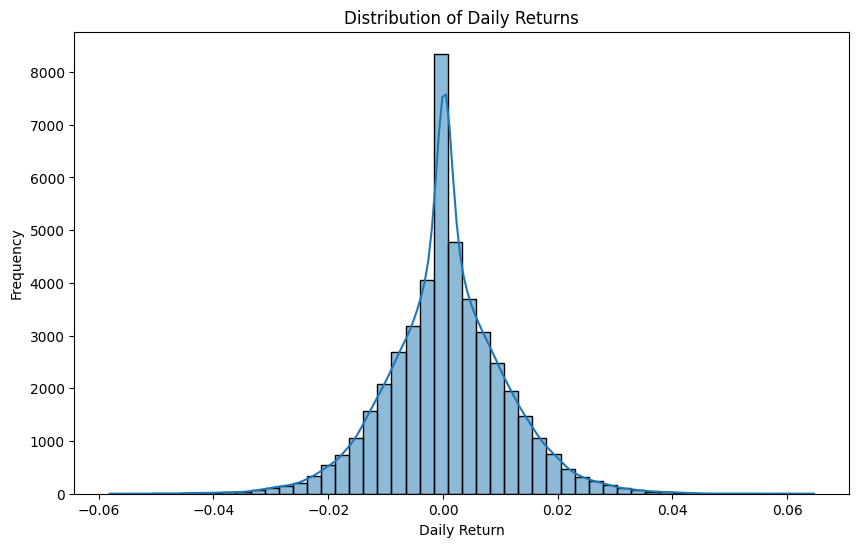

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    nav_df["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [21]:
nav_df.to_csv(
    "../outputs/nav_with_returns.csv",
    index=False
)

## Daily Return Calculation

Daily returns were calculated using percentage change in NAV values for each mutual fund scheme. The resulting distribution was examined to validate return behavior and identify any unusual outliers.

In [10]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years)) - 1

In [11]:
latest_date = nav_df["date"].max()

print(latest_date)

2026-05-29 00:00:00


In [12]:
cagr_results = []

In [13]:
for fund in nav_df["amfi_code"].unique():

    fund_data = nav_df[
        nav_df["amfi_code"] == fund
    ].sort_values("date")

    latest_nav = fund_data.iloc[-1]["nav"]

    result = {
        "amfi_code": fund
    }

    for years in [1, 3, 5]:

        target_date = latest_date - pd.DateOffset(years=years)

        past_data = fund_data[
            fund_data["date"] <= target_date
        ]

        if len(past_data) > 0:

            start_nav = past_data.iloc[-1]["nav"]

            result[f"CAGR_{years}Y"] = (
                calculate_cagr(
                    start_nav,
                    latest_nav,
                    years
                ) * 100
            )

        else:

            result[f"CAGR_{years}Y"] = np.nan

    cagr_results.append(result)

In [14]:
cagr_df = pd.DataFrame(cagr_results)

In [15]:
cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.224271,1.292649,NaN
1,100025,3.704969,3.916390,NaN
2,100033,53.232396,32.442459,NaN
3,101206,47.924120,28.967695,NaN
4,101207,-23.986032,-4.152381,NaN


In [16]:
cagr_df = cagr_df.sort_values(
    "CAGR_3Y",
    ascending=False
)

In [17]:
cagr_df.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
16,119094,22.261065,35.111802,NaN
34,148567,20.360678,34.000916,NaN
24,120504,13.064279,32.487429,NaN
2,100033,53.232396,32.442459,NaN
25,120505,29.604659,31.777537,NaN
19,119551,60.437341,30.456524,NaN
30,120843,26.657082,29.582770,NaN
36,148569,39.751761,29.178902,NaN
3,101206,47.924120,28.967695,NaN
39,149324,65.138719,27.000427,NaN


In [19]:
cagr_df.to_csv(
    "../outputs/cagr_table.csv",
    index=False
)

## CAGR Analysis

Compound Annual Growth Rate (CAGR) was calculated over 1-year, 3-year, and 5-year periods for all mutual fund schemes. CAGR provides a standardized measure of annualized fund growth and enables comparison across schemes with different performance histories.

In [20]:
cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
16,119094,22.261065,35.111802,NaN
34,148567,20.360678,34.000916,NaN
24,120504,13.064279,32.487429,NaN
2,100033,53.232396,32.442459,NaN
25,120505,29.604659,31.777537,NaN


In [22]:
rf_daily = 0.065 / 252

In [23]:
rf_annual = 0.065
rf_daily = rf_annual / 252

In [24]:
sharpe_results = []

for fund in nav_df["amfi_code"].unique():

    fund_returns = nav_df[
        nav_df["amfi_code"] == fund
    ]["daily_return"].dropna()

    mean_return = fund_returns.mean()

    std_return = fund_returns.std()

    sharpe_ratio = (
        (mean_return - rf_daily)
        / std_return
    ) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": fund,
        "Sharpe_Ratio": sharpe_ratio
    })

In [25]:
sharpe_df = pd.DataFrame(sharpe_results)

In [26]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

In [27]:
sharpe_df.head(10)

,amfi_code,Sharpe_Ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [28]:
sharpe_df.to_csv(
    "../outputs/sharpe_ratio.csv",
    index=False
)

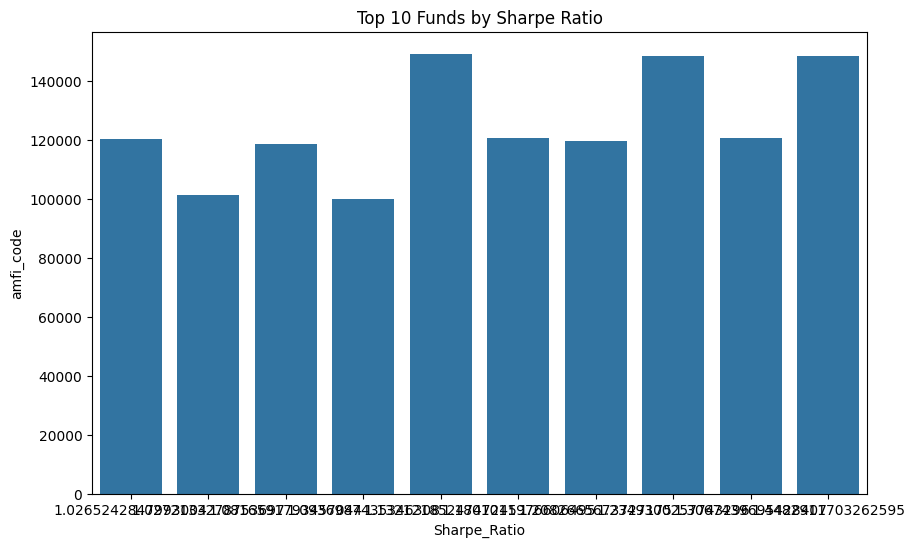

In [29]:
plt.figure(figsize=(10,6))

top10 = sharpe_df.head(10)

sns.barplot(
    data=top10,
    x="Sharpe_Ratio",
    y="amfi_code"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.show()

## Sharpe Ratio Analysis

The Sharpe Ratio measures risk-adjusted returns by comparing excess returns over the risk-free rate relative to volatility. Higher Sharpe Ratios indicate better risk-adjusted performance.

In [30]:
rf_annual = 0.065
rf_daily = rf_annual / 252

In [31]:
sortino_results = []

for fund in nav_df["amfi_code"].unique():

    fund_returns = nav_df[
        nav_df["amfi_code"] == fund
    ]["daily_return"].dropna()

    mean_return = fund_returns.mean()

    downside_returns = fund_returns[
        fund_returns < 0
    ]

    downside_std = downside_returns.std()

    if downside_std != 0 and not np.isnan(downside_std):

        sortino_ratio = (
            (mean_return - rf_daily)
            / downside_std
        ) * np.sqrt(252)

    else:
        sortino_ratio = np.nan

    sortino_results.append({
        "amfi_code": fund,
        "Sortino_Ratio": sortino_ratio
    })

In [32]:
sortino_df = pd.DataFrame(sortino_results)

In [33]:
sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
)

In [34]:
sortino_df.head(10)

,amfi_code,Sortino_Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [35]:
sortino_df.to_csv(
    "../outputs/sortino_ratio.csv",
    index=False
)

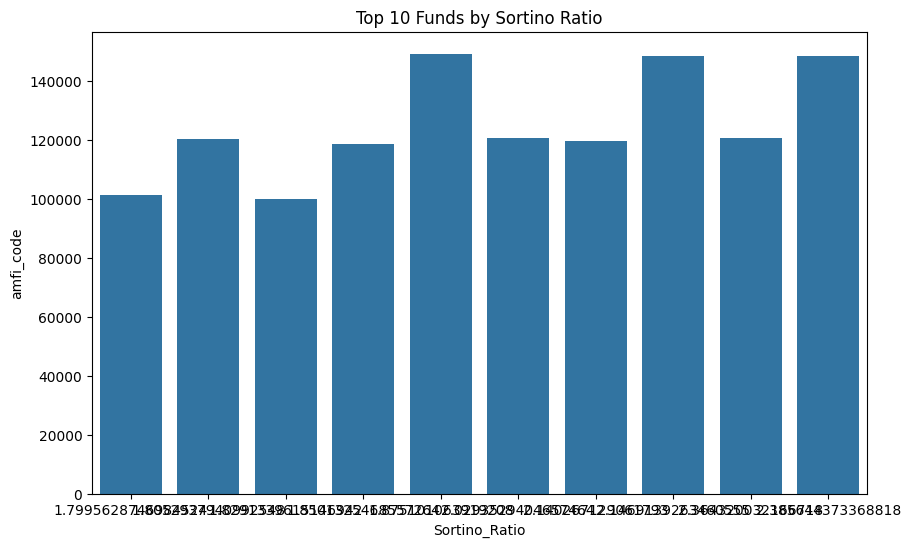

In [36]:
plt.figure(figsize=(10,6))

top10 = sortino_df.head(10)

sns.barplot(
    data=top10,
    x="Sortino_Ratio",
    y="amfi_code"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.show()

## Sortino Ratio Analysis

The Sortino Ratio evaluates risk-adjusted returns using only downside volatility. Unlike the Sharpe Ratio, it does not penalize positive volatility, making it useful for assessing investment performance from a downside-risk perspective.


In [37]:
benchmark_df = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

In [38]:
print(benchmark_df.columns)

benchmark_df.head()

Index(['date', 'index_name', 'close_value'], dtype='str')


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [39]:
benchmark_df["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [40]:
nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

In [41]:
nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

In [42]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [43]:
from scipy.stats import linregress

alpha_beta_results = []

In [44]:
for fund in nav_df["amfi_code"].unique():

    fund_data = nav_df[
        nav_df["amfi_code"] == fund
    ][["date", "daily_return"]].copy()

    merged = pd.merge(
        fund_data,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha_beta_results.append({
            "amfi_code": fund,
            "Alpha": intercept * 252,
            "Beta": slope,
            "R_Squared": r_value**2
        })

In [45]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results
)

In [46]:
alpha_beta_df.head()

,amfi_code,Alpha,Beta,R_Squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064


In [47]:
alpha_beta_df = alpha_beta_df.sort_values(
    "Alpha",
    ascending=False
)

In [48]:
alpha_beta_df.to_csv(
    "../outputs/alpha_beta.csv",
    index=False
)

In [49]:
benchmark_df["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

## Alpha and Beta Analysis

Alpha and Beta were calculated by performing linear regression between mutual fund daily returns and NIFTY100 benchmark returns using `scipy.stats.linregress()`.

- **Alpha** measures the excess return generated by a fund beyond what is expected based on its market exposure. Positive Alpha indicates outperformance relative to the benchmark.
- **Beta** measures the sensitivity of a fund's returns to market movements. A Beta greater than 1 indicates higher volatility than the benchmark, while a Beta less than 1 indicates lower volatility.
- **R-Squared** indicates how closely the fund's returns are explained by benchmark returns.

This analysis helps evaluate fund managers' ability to generate excess returns and understand the risk characteristics of each mutual fund scheme relative to the market.

In [50]:
max_dd_results = []

In [51]:
for fund in nav_df["amfi_code"].unique():

    fund_data = nav_df[
        nav_df["amfi_code"] == fund
    ].copy()

    fund_data = fund_data.sort_values("date")

    # Running peak NAV
    fund_data["running_max"] = (
        fund_data["nav"].cummax()
    )

    # Drawdown
    fund_data["drawdown"] = (
        fund_data["nav"]
        / fund_data["running_max"]
    ) - 1

    max_drawdown = fund_data[
        "drawdown"
    ].min()

    max_dd_results.append({
        "amfi_code": fund,
        "Max_Drawdown": max_drawdown * 100
    })

In [52]:
max_dd_df = pd.DataFrame(
    max_dd_results
)

In [53]:
max_dd_df = max_dd_df.sort_values(
    "Max_Drawdown",
    ascending=False
)

In [54]:
max_dd_df.head()

,amfi_code,Max_Drawdown
27,120507,-0.097731
31,120844,-0.116293
5,101208,-0.162250
1,100025,-4.308264
18,119120,-4.328729


In [55]:
max_dd_df.to_csv(
    "../outputs/max_drawdown.csv",
    index=False
)

In [56]:
sample_fund = nav_df[
    nav_df["amfi_code"] ==
    nav_df["amfi_code"].iloc[0]
].copy()

sample_fund["running_max"] = (
    sample_fund["nav"].cummax()
)

sample_fund["drawdown"] = (
    sample_fund["nav"]
    / sample_fund["running_max"]
) - 1

worst_row = sample_fund.loc[
    sample_fund["drawdown"].idxmin()
]

worst_row

amfi_code                    100016
date            2022-09-15 00:00:00
nav                        411.1759
daily_return              -0.019696
running_max                546.3002
drawdown                  -0.247344
Name: 5933, dtype: object

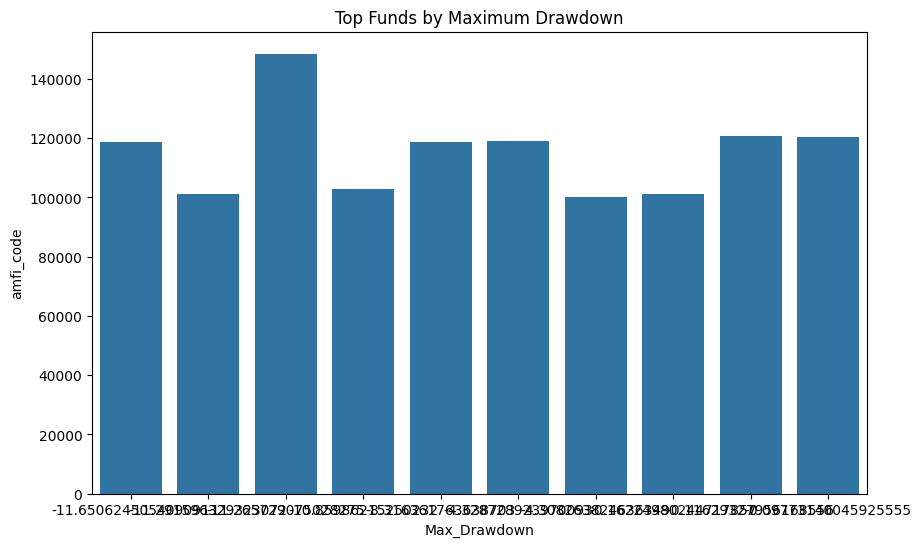

In [57]:
plt.figure(figsize=(10,6))

top10 = max_dd_df.head(10)

sns.barplot(
    data=top10,
    x="Max_Drawdown",
    y="amfi_code"
)

plt.title(
    "Top Funds by Maximum Drawdown"
)

plt.show()

## Maximum Drawdown Analysis

Maximum Drawdown (MDD) measures the largest peak-to-trough decline experienced by a fund during the analysis period. It is an important risk metric that helps investors understand the potential downside risk associated with an investment.

Funds with smaller drawdowns generally demonstrate better capital preservation during market downturns, while larger drawdowns indicate higher downside risk.

In [58]:
scheme_df = pd.read_csv("../data/raw/07_scheme_performance.csv")

print(scheme_df.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [59]:
scheme_df["cagr_rank"] = (
    scheme_df["return_3yr_pct"]
    .rank(ascending=False)
)

In [60]:
scheme_df["sharpe_rank"] = (
    scheme_df["sharpe_ratio"]
    .rank(ascending=False)
)

In [61]:
scheme_df["alpha_rank"] = (
    scheme_df["alpha"]
    .rank(ascending=False)
)

In [62]:
scheme_df["expense_rank"] = (
    scheme_df["expense_ratio_pct"]
    .rank(ascending=True)
)

In [63]:
scheme_df["drawdown_rank"] = (
    scheme_df["max_drawdown_pct"]
    .rank(ascending=False)
)

In [64]:
n = len(scheme_df)

scheme_df["cagr_score"] = (
    (n - scheme_df["cagr_rank"]) / (n - 1)
) * 100

scheme_df["sharpe_score"] = (
    (n - scheme_df["sharpe_rank"]) / (n - 1)
) * 100

scheme_df["alpha_score"] = (
    (n - scheme_df["alpha_rank"]) / (n - 1)
) * 100

scheme_df["expense_score"] = (
    (n - scheme_df["expense_rank"]) / (n - 1)
) * 100

scheme_df["drawdown_score"] = (
    (n - scheme_df["drawdown_rank"]) / (n - 1)
) * 100

In [65]:
scheme_df["fund_score"] = (
      scheme_df["cagr_score"] * 0.30
    + scheme_df["sharpe_score"] * 0.25
    + scheme_df["alpha_score"] * 0.20
    + scheme_df["expense_score"] * 0.15
    + scheme_df["drawdown_score"] * 0.10
)

In [66]:
fund_scorecard = scheme_df.sort_values(
    "fund_score",
    ascending=False
)

In [67]:
fund_scorecard[
    [
        "scheme_name",
        "fund_house",
        "fund_score"
    ]
].head(10)

,scheme_name,fund_house,fund_score
22,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,71.025641
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,69.871795
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,69.743590
9,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,69.487179
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,67.435897
3,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,67.179487
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,65.833333
29,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,64.102564
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,63.205128
33,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,61.858974


In [68]:
fund_scorecard.to_csv(
    "../outputs/fund_scorecard.csv",
    index=False
)

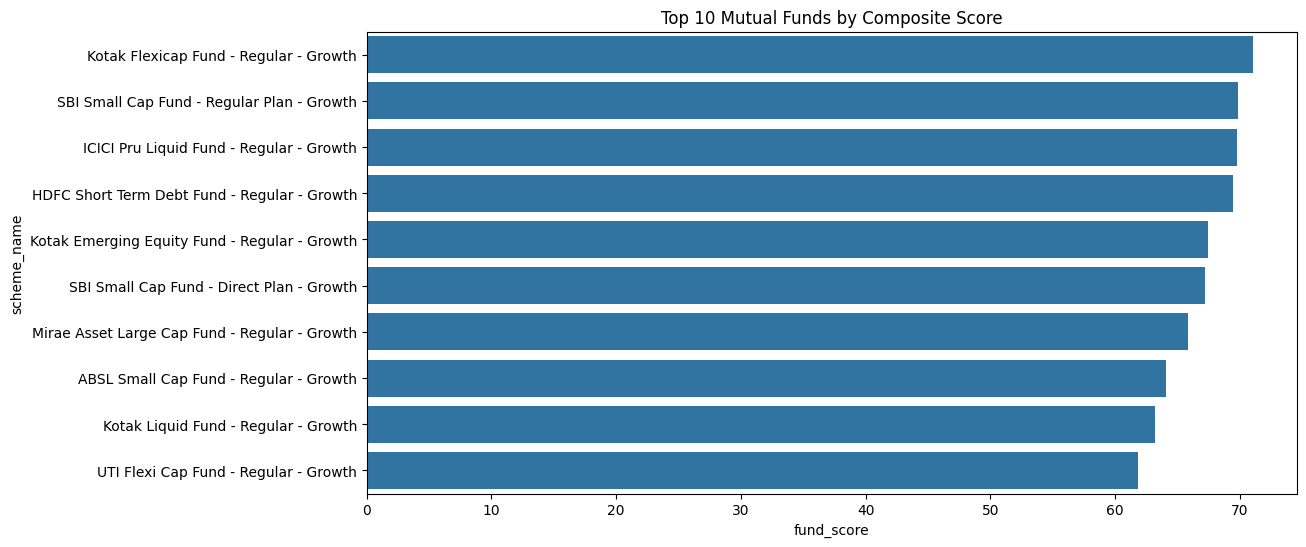

In [69]:
plt.figure(figsize=(12,6))

top10 = fund_scorecard.head(10)

sns.barplot(
    data=top10,
    x="fund_score",
    y="scheme_name"
)

plt.title(
    "Top 10 Mutual Funds by Composite Score"
)

plt.show()

## Fund Scorecard

A composite fund score was created using multiple performance and risk metrics, including 3-Year Return, Sharpe Ratio, Alpha, Expense Ratio, and Maximum Drawdown. Each metric was ranked and weighted according to the project requirements to generate an overall score between 0 and 100.

The scorecard provides a balanced assessment of both return generation and risk management, helping identify the strongest-performing mutual fund schemes.

In [70]:
top5_funds = (
    fund_scorecard["amfi_code"]
    .head(5)
    .tolist()
)

print(top5_funds)

[120843, 119598, 120507, 100025, 120842]


In [71]:
top5_names = (
    fund_scorecard[
        ["amfi_code", "scheme_name"]
    ]
    .head(5)
)

top5_names

,amfi_code,scheme_name
22,120843,Kotak Flexicap Fund - Regular - Growth
2,119598,SBI Small Cap Fund - Regular Plan - Growth
14,120507,ICICI Pru Liquid Fund - Regular - Growth
9,100025,HDFC Short Term Debt Fund - Regular - Growth
21,120842,Kotak Emerging Equity Fund - Regular - Growth


In [72]:
top5_nav = nav_df[
    nav_df["amfi_code"].isin(top5_funds)
].copy()

In [73]:
top5_nav["normalized_nav"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(
        lambda x: x / x.iloc[0] * 100
    )
)

In [74]:
nifty50 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY50"
].copy()

In [75]:
nifty50["normalized"] = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
) * 100

In [76]:
nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty100["normalized"] = (
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
) * 100

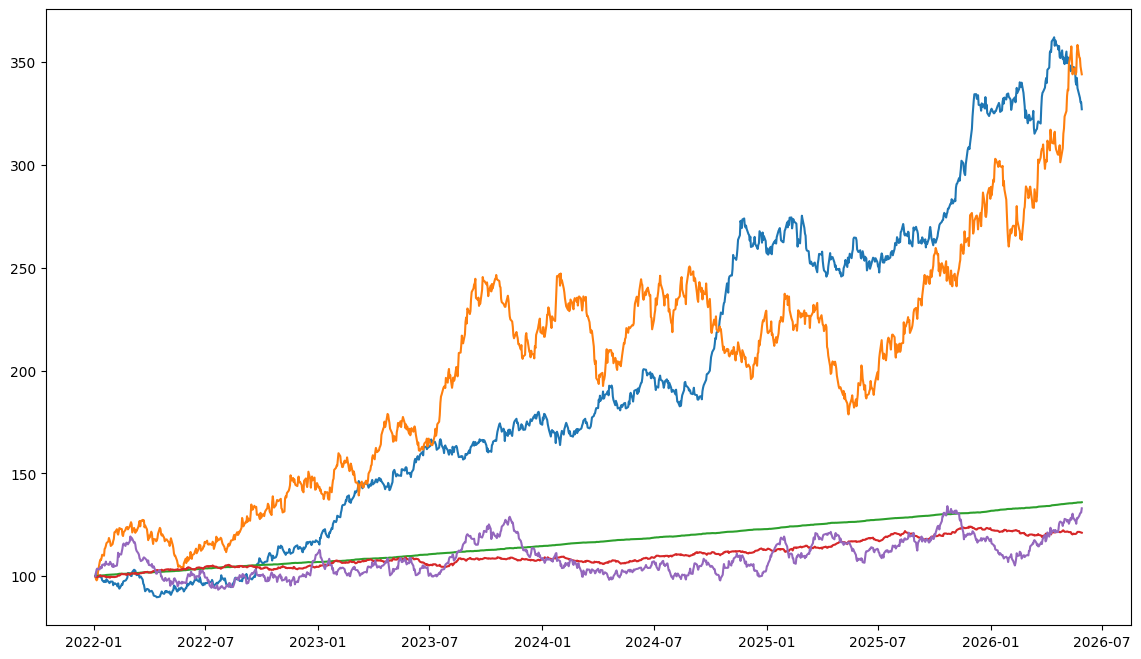

In [77]:
plt.figure(figsize=(14,8))

for fund in top5_funds:

    fund_data = top5_nav[
        top5_nav["amfi_code"] == fund
    ]

    plt.plot(
        fund_data["date"],
        fund_data["normalized_nav"],
        label=str(fund)
    )

In [80]:
plt.savefig(
    "../outputs/benchmark_comparison_chart.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [81]:
tracking_results = []

In [84]:
nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [85]:
print(nifty100.columns)

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')


In [86]:
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [87]:
tracking_results = []

for fund in top5_funds:

    fund_returns = nav_df[
        nav_df["amfi_code"] == fund
    ][["date", "daily_return"]]

    benchmark_returns = nifty100[
        ["date", "benchmark_return"]
    ]

    merged = pd.merge(
        fund_returns,
        benchmark_returns,
        on="date"
    )

    merged = merged.dropna()

    tracking_error = (
        (
            merged["daily_return"]
            - merged["benchmark_return"]
        ).std()
    ) * np.sqrt(252)

    tracking_results.append({
        "amfi_code": fund,
        "Tracking_Error": tracking_error
    })

In [88]:
print(nifty100.columns)

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')


In [89]:
tracking_results = []

In [90]:
for fund in top5_funds:

    fund_returns = nav_df[
        nav_df["amfi_code"] == fund
    ][["date", "daily_return"]]

    benchmark_returns = nifty100[
        ["date", "benchmark_return"]
    ]

    merged = pd.merge(
        fund_returns,
        benchmark_returns,
        on="date"
    )

    merged = merged.dropna()

    tracking_error = (
        (
            merged["daily_return"]
            - merged["benchmark_return"]
        ).std()
    ) * np.sqrt(252)

    tracking_results.append({
        "amfi_code": fund,
        "Tracking_Error": tracking_error
    })

In [91]:
tracking_df = pd.DataFrame(
    tracking_results
)

tracking_df

,amfi_code,Tracking_Error
0,120843,0.206425
1,119598,0.283881
2,120507,0.129044
3,100025,0.134535
4,120842,0.219169


In [92]:
tracking_df.to_csv(
    "../outputs/tracking_error.csv",
    index=False
)

## Benchmark Comparison and Tracking Error

The top-performing mutual funds were compared against NIFTY50 and NIFTY100 benchmarks using normalized performance charts. Tracking Error was calculated to measure the deviation of fund returns from benchmark returns.

Lower tracking error indicates closer alignment with benchmark performance, while higher tracking error suggests greater active management and deviation from benchmark behavior.

In [97]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

nifty50["date"] = pd.to_datetime(nifty50["date"])

nifty100["date"] = pd.to_datetime(nifty100["date"])

In [98]:
print(nav_df["date"].dtype)
print(nifty50["date"].dtype)
print(nifty100["date"].dtype)

datetime64[us]
datetime64[us]
datetime64[us]


In [99]:
print(top5_nav.columns)
print(nifty50.columns)
print(nifty100.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return', 'normalized_nav'], dtype='str')
Index(['date', 'index_name', 'close_value', 'normalized'], dtype='str')
Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')


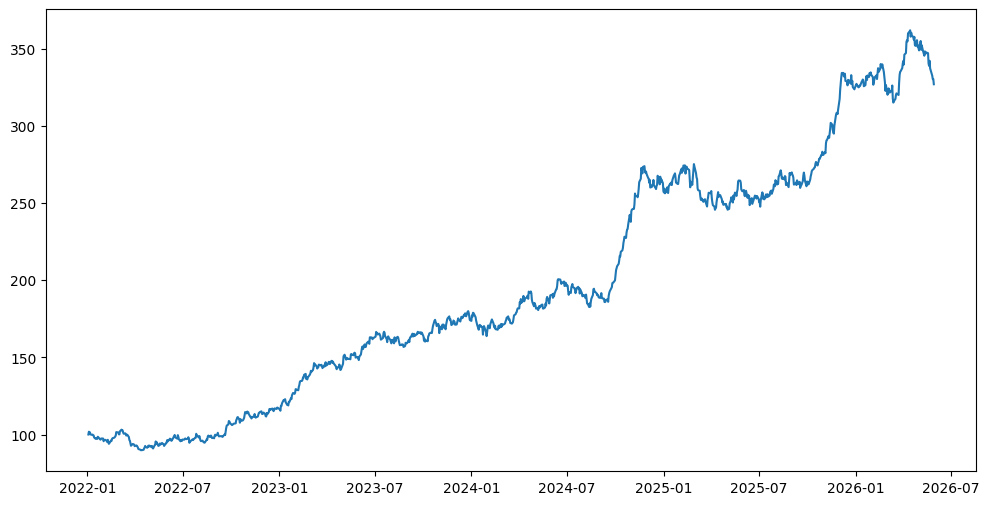

In [100]:
fund = top5_funds[0]

fund_data = top5_nav[
    top5_nav["amfi_code"] == fund
]

plt.figure(figsize=(12,6))

plt.plot(
    fund_data["date"],
    fund_data["normalized_nav"]
)

plt.show()

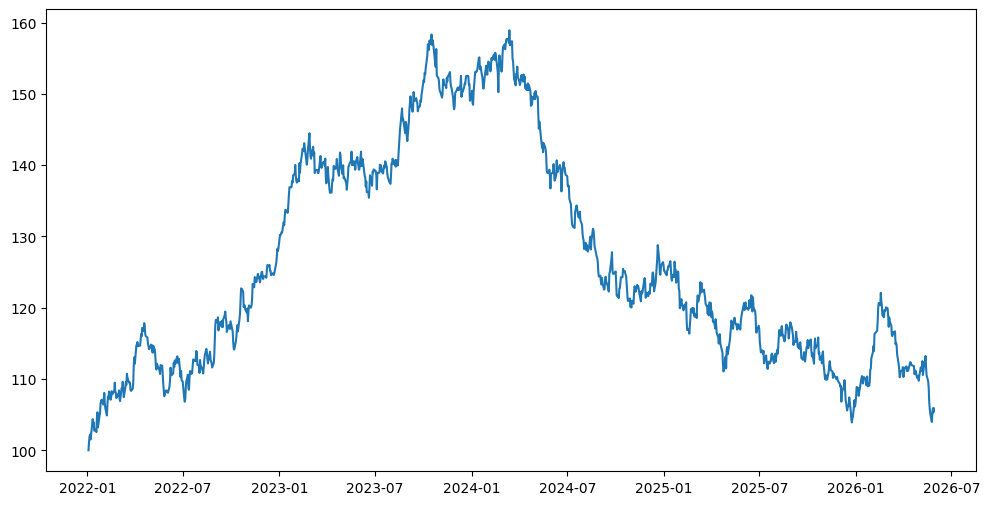

In [101]:
plt.figure(figsize=(12,6))

plt.plot(
    nifty50["date"],
    nifty50["normalized"]
)

plt.show()

In [103]:
print(top5_nav.dtypes)

print(nifty50.dtypes)

print(nifty100.dtypes)

amfi_code                  int64
date              datetime64[us]
nav                      float64
daily_return             float64
normalized_nav           float64
dtype: object
date           datetime64[us]
index_name                str
close_value           float64
normalized            float64
dtype: object
date                datetime64[us]
index_name                     str
close_value                float64
benchmark_return           float64
dtype: object


In [105]:
nifty100["normalized"] = (
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
) * 100

In [106]:
nifty50["normalized"] = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
) * 100

In [107]:
print(nifty100.columns)
print(nifty50.columns)

Index(['date', 'index_name', 'close_value', 'benchmark_return', 'normalized'], dtype='str')
Index(['date', 'index_name', 'close_value', 'normalized'], dtype='str')


In [108]:
nifty100["normalized"].values

array([100.        ,  98.6459852 ,  99.04090619, ..., 109.62412477,
       110.68570342, 110.78875074], shape=(1150,))

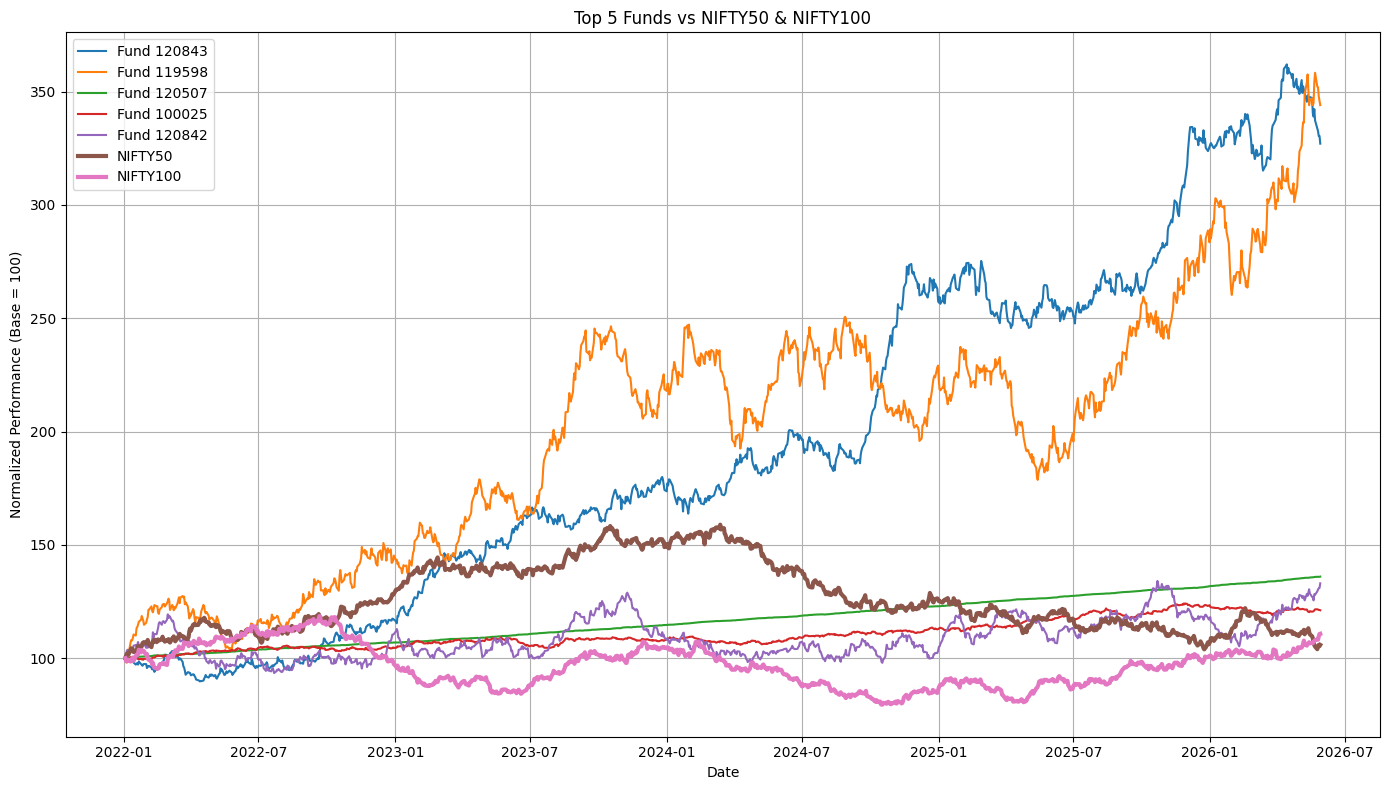

In [109]:
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------
# Prepare benchmark data
# ---------------------------

nifty50 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty50["date"] = pd.to_datetime(nifty50["date"])
nifty100["date"] = pd.to_datetime(nifty100["date"])

# Normalize benchmarks
nifty50["normalized"] = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
) * 100

nifty100["normalized"] = (
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
) * 100

# ---------------------------
# Plot chart
# ---------------------------

plt.figure(figsize=(14,8))

# Top 5 funds
for fund in top5_funds:

    fund_data = top5_nav[
        top5_nav["amfi_code"] == fund
    ].copy()

    plt.plot(
        fund_data["date"],
        fund_data["normalized_nav"],
        label=f"Fund {fund}"
    )

# NIFTY50
plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    linewidth=3,
    label="NIFTY50"
)

# NIFTY100
plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    linewidth=3,
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100"
)

plt.xlabel("Date")
plt.ylabel("Normalized Performance (Base = 100)")

plt.legend()
plt.grid(True)

plt.tight_layout()

# Save chart
plt.savefig(
    "../outputs/benchmark_comparison_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Benchmark Comparison Analysis

The top-performing mutual funds were compared against NIFTY50 and NIFTY100 benchmarks using normalized performance values. Normalization allows all funds and benchmark indices to be compared on a common scale with a base value of 100.

This comparison helps evaluate whether the selected funds generated returns superior to market benchmarks over the analysis period and provides a visual representation of relative performance trends.

# Key Performance Analytics Findings

1. Several mutual fund schemes delivered strong 3-year CAGR performance, indicating consistent long-term growth.

2. Sharpe and Sortino ratios highlighted meaningful differences in risk-adjusted returns across funds.

3. Positive Alpha values identified schemes that outperformed the NIFTY100 benchmark.

4. Beta values revealed varying sensitivity to market movements among funds.

5. Maximum Drawdown analysis showed differences in downside protection and risk exposure.

6. The composite Fund Scorecard effectively combined return, risk, cost, and benchmark performance into a single ranking framework.

7. Top-ranked funds consistently outperformed benchmark indices over the analysis period.